In [2]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from google.colab import drive
import sys
import math

## Variables

## Directory Setup

In [3]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [4]:
def extract_metrics(json_files):
    """
    Extract total distance and total time from multiple JSON files.
    Ensures only valid data is used and avoids incorrect default values.
    """
    total_distances = []
    avg_times = []
    success_rate = []
    shares = []

    for file_path in json_files:
        with open(file_path, 'r') as file:
            data = json.load(file)

        if "distances" in data and "times" in data and len(data["times"]) > 0:
            total_distances.append(sum([d / 1000 for d in data["distances"]]))
            avg_times.append(np.mean(data["times"]))
            success_rate.append(data["success_rate"])
            shares.append(data["shares"])

    # If no valid data is found, return None to indicate the model should be skipped.
    if not total_distances or not avg_times:
        return None

    return {
        "total_distance": np.mean(total_distances),  # Average for line plot
        "average_time": np.mean(avg_times),        # Average for line plot
        "all_distances": total_distances,            # List of all values for scatter plot
        "all_avg_times": avg_times,                     # List of all values for scatter plot
        "success_rate": success_rate,
        "shares": shares
    }


def process_city_data(base_directory, models):
    """
    Process all super-hotspot ratio folders in the city's Results directory.
    Ensures only valid models with data are included in results.
    """
    results = {}

    for ratio_folder in os.listdir(base_directory):
        ratio_path = os.path.join(base_directory, ratio_folder, "Repeating")
        if not os.path.isdir(ratio_path):
            continue

        ratio = int(ratio_folder.split('-')[-1])  # Extract ratio from folder name
        results[ratio] = {}

        for model in models:
            json_files = [
                os.path.join(ratio_path, f) for f in os.listdir(ratio_path)
                if f.startswith(model) and "-0300-" in f and f.endswith(".json")
            ]

            metrics = extract_metrics(json_files)

            if metrics:  # Only add models that have valid data
                results[ratio][model] = metrics

    return results

In [5]:
# ScatterPlot
# Define professional-style colors for consistency
model_colors = {
    "results": "#1f77b4",  # Blue
    "baseline1": "#ff7f0e",  # Orange
    "baseline2": "#2ca02c",  # Green
}

model_styles = {
    "results": {"color": "#1f77b4", "linestyle": "-", "marker": "o"},  # Solid
    "baseline1": {"color": "#ff7f0e", "linestyle": ":", "marker": "s"},  # Dotted
    "baseline2": {"color": "#2ca02c", "linestyle": "--", "marker": "d"},  # Dashed
}

# Define font size variables
TITLE_FONT_SIZE = 18
AXIS_LABEL_FONT_SIZE = 16
TICK_LABEL_FONT_SIZE = 14
LEGEND_FONT_SIZE = 16
LEGEND_TITLE_FONT_SIZE = 18

def plot_results(city_results_dict, models):
    """
    Creates a single figure with:
    - First row: Total Distance plots for all cities
    - Second row: Average Time plots for all cities
    - Integrated legend at the bottom (outside subplots).
    """
    num_cities = len(city_results_dict)
    fig, axes = plt.subplots(2, num_cities, figsize=(5 * num_cities, 10))

    for idx, (city, results) in enumerate(city_results_dict.items()):
        ratios = sorted(results.keys())

        # **Plot Total Distance (Top Row)**
        ax1 = axes[0, idx]
        for model in models:
            if not any(model in results[r] for r in ratios):
                continue

            distances = [results[r][model]["total_distance"] for r in ratios if model in results[r]]
            all_distances = [results[r][model]["all_distances"] for r in ratios if model in results[r]]
            valid_ratios = [r for r in ratios if model in results[r]]

            style = model_styles.get(model, {"color": "gray", "linestyle": "-", "marker": "o"})
            linewidth = 3 if model == "results" else 1.8
            markersize = 9 if model == "results" else 6

            ax1.plot(valid_ratios, distances, linestyle=style["linestyle"], marker=style["marker"],
                     color=style["color"], markersize=markersize, linewidth=linewidth, label=model)

            for i, r in enumerate(valid_ratios):
                ax1.scatter([r] * len(all_distances[i]), all_distances[i], color=style["color"], alpha=0.6)

        ax1.set_title(f"Total Distance - {city}", fontsize=TITLE_FONT_SIZE)
        ax1.set_xlabel("Super-Hotspot Ratio", fontsize=AXIS_LABEL_FONT_SIZE)
        ax1.set_ylabel("Total Distance (km)", fontsize=AXIS_LABEL_FONT_SIZE)
        ax1.set_xticks(valid_ratios)
        ax1.tick_params(axis='both', labelsize=TICK_LABEL_FONT_SIZE)
        ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

        # **Plot Average Time (Bottom Row)**
        ax2 = axes[1, idx]
        for model in models:
            if not any(model in results[r] for r in ratios):
                continue

            avg_times = [results[r][model]["average_time"] for r in ratios if model in results[r]]
            all_times = [results[r][model]["all_avg_times"] for r in ratios if model in results[r]]
            valid_ratios = [r for r in ratios if model in results[r]]

            style = model_styles.get(model, {"color": "gray", "linestyle": "-", "marker": "o"})
            linewidth = 3 if model == "results" else 1.8
            markersize = 9 if model == "results" else 6

            ax2.plot(valid_ratios, avg_times, linestyle=style["linestyle"], marker=style["marker"],
                     color=style["color"], markersize=markersize, linewidth=linewidth, label=model)

            for i, r in enumerate(valid_ratios):
                ax2.scatter([r] * len(all_times[i]), all_times[i], color=style["color"], alpha=0.6)

        ax2.set_title(f"Average Time - {city}", fontsize=TITLE_FONT_SIZE)
        ax2.set_xlabel("Super-Hotspot Ratio", fontsize=AXIS_LABEL_FONT_SIZE)
        ax2.set_ylabel("Average Time (s)", fontsize=AXIS_LABEL_FONT_SIZE)
        ax2.set_xticks(valid_ratios)
        ax2.tick_params(axis='both', labelsize=TICK_LABEL_FONT_SIZE)
        ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # **Integrate the Legend Below the Graphs**
    legend_handles = [
        plt.Line2D([0], [0], color=model_styles["baseline1"]["color"], linestyle=model_styles["baseline1"]["linestyle"],
                   lw=2, marker=model_styles["baseline1"]["marker"], markersize=6, label="Baseline1"),
        plt.Line2D([0], [0], color=model_styles["baseline2"]["color"], linestyle=model_styles["baseline2"]["linestyle"],
                   lw=2, marker=model_styles["baseline2"]["marker"], markersize=6, label="Baseline2"),
        plt.Line2D([0], [0], color=model_styles["results"]["color"], linestyle=model_styles["results"]["linestyle"],
                   lw=3, marker=model_styles["results"]["marker"], markersize=8, label="Results"),
    ]

    fig.legend(handles=legend_handles, loc="lower center", fontsize=LEGEND_FONT_SIZE, title="Model Line Styles", title_fontsize=LEGEND_TITLE_FONT_SIZE,
               frameon=False, ncol=3)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to fit the legend
    plt.show()

In [6]:
# Barplot
import matplotlib.pyplot as plt
import pandas as pd

# Define professional-style colors & hatch patterns for clarity in black & white
model_styles_barplot = {
    "results": {"color": "#1f77b4", "hatch": "/", "edgecolor": "black"},  # Diagonal hatch
    "baseline1": {"color": "#ff7f0e", "hatch": "\\", "edgecolor": "black"},  # Opposite diagonal hatch
    "baseline2": {"color": "#2ca02c", "hatch": "-", "edgecolor": "black"},  # Horizontal hatch
}

def plot_all_cities_bar_plot(city_results_dict, models):
    """
    Creates a single figure with two rows of grouped bar charts for all cities.
    - First row: Total Distance per Model across Hotspot Ratios
    - Second row: Average Time per Model across Hotspot Ratios
    - Integrated legend below the graphs.
    - Highlights 'Results' model with a border effect.
    """
    num_cities = len(city_results_dict)
    fig, axes = plt.subplots(2, num_cities, figsize=(5 * num_cities, 10), sharey=False)

    for idx, (city, results) in enumerate(city_results_dict.items()):
        # Convert to DataFrame for Total Distance
        df_distance = []
        df_time = []
        for ratio, model_data in results.items():
            for model, metrics in model_data.items():
                df_distance.append([ratio, model, metrics["total_distance"]])
                df_time.append([ratio, model, metrics["average_time"]])

        df_distance = pd.DataFrame(df_distance, columns=["Hotspot Ratio", "Model", "Total Distance"])
        df_time = pd.DataFrame(df_time, columns=["Hotspot Ratio", "Model", "Average Time"])

        # Pivot for bar chart format
        df_pivot_distance = df_distance.pivot(index="Hotspot Ratio", columns="Model", values="Total Distance")
        df_pivot_time = df_time.pivot(index="Hotspot Ratio", columns="Model", values="Average Time")

        # **Plot Total Distance (Top Row)**
        bars_distance = df_pivot_distance.plot(kind="bar", ax=axes[0, idx],
                                               color=[model_styles_barplot.get(model, {}).get("color", "gray")
                                                      for model in df_pivot_distance.columns],
                                               legend=False)

        axes[0, idx].set_title(f"Total Distance - {city}", fontsize=14)
        axes[0, idx].set_xlabel("Hotspot Ratio", fontsize=12)
        axes[0, idx].set_ylabel("Total Distance (km)", fontsize=12 if idx == 0 else 0)  # Label only first plot for clarity
        axes[0, idx].tick_params(axis='x', rotation=0)

        # **Apply Hatch Patterns and Borders**
        for container, model in zip(bars_distance.containers, df_pivot_distance.columns):
            style = model_styles_barplot.get(model, {"hatch": "", "edgecolor": "black"})
            for bar in container:
                bar.set_edgecolor(style["edgecolor"])
                bar.set_linewidth(1.2)
                bar.set_hatch(style["hatch"])

        # **Plot Average Time (Bottom Row)**
        bars_time = df_pivot_time.plot(kind="bar", ax=axes[1, idx],
                                       color=[model_styles_barplot.get(model, {}).get("color", "gray")
                                              for model in df_pivot_time.columns],
                                       legend=False)

        axes[1, idx].set_title(f"Average Time - {city}", fontsize=14)
        axes[1, idx].set_xlabel("Hotspot Ratio", fontsize=12)
        axes[1, idx].set_ylabel("Average Time (s)", fontsize=12 if idx == 0 else 0)
        axes[1, idx].tick_params(axis='x', rotation=0)

        # **Apply Hatch Patterns and Borders for Average Time Plots**
        for container, model in zip(bars_time.containers, df_pivot_time.columns):
            style = model_styles_barplot.get(model, {"hatch": "", "edgecolor": "black"})
            for bar in container:
                bar.set_edgecolor(style["edgecolor"])
                bar.set_linewidth(1.2)
                bar.set_hatch(style["hatch"])

    # **Integrated Legend Below the Graphs**
    legend_handles = [
        plt.Line2D([0], [0], color=model_styles_barplot["baseline1"]["color"], lw=3, label="Baseline1", linestyle="-"),
        plt.Line2D([0], [0], color=model_styles_barplot["baseline2"]["color"], lw=3, label="Baseline2", linestyle="--"),
        plt.Line2D([0], [0], color=model_styles_barplot["results"]["color"], lw=3, label="Results", linestyle=":"),
    ]

    fig.legend(handles=legend_handles, loc="lower center", fontsize=12, title="Model Styles", title_fontsize=13,
               frameon=False, ncol=3)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to fit the legend
    plt.show()


In [7]:
# from time import thread_time
# Main Execution
cities = ["Philadelphia", "Columbus", "Chicago", "Chicago_mini", "City of New York"]
models = ["results", "baseline1", "baseline2"]
personal_dir = "./gdrive/MyDrive/DeliverAI Data Folder/"
city_results_dict = {}

# Process and Store Results
for city in cities:
    base_directory = os.path.join(personal_dir, f"{city} - RL Delivery Data", "Results")
    city_results = process_city_data(base_directory, models)
    print(f"City: {city}\n")
    # Store city results in the dictionary
    city_results_dict[city] = city_results

City: Philadelphia

City: Columbus

City: Chicago

City: Chicago_mini

City: City of New York



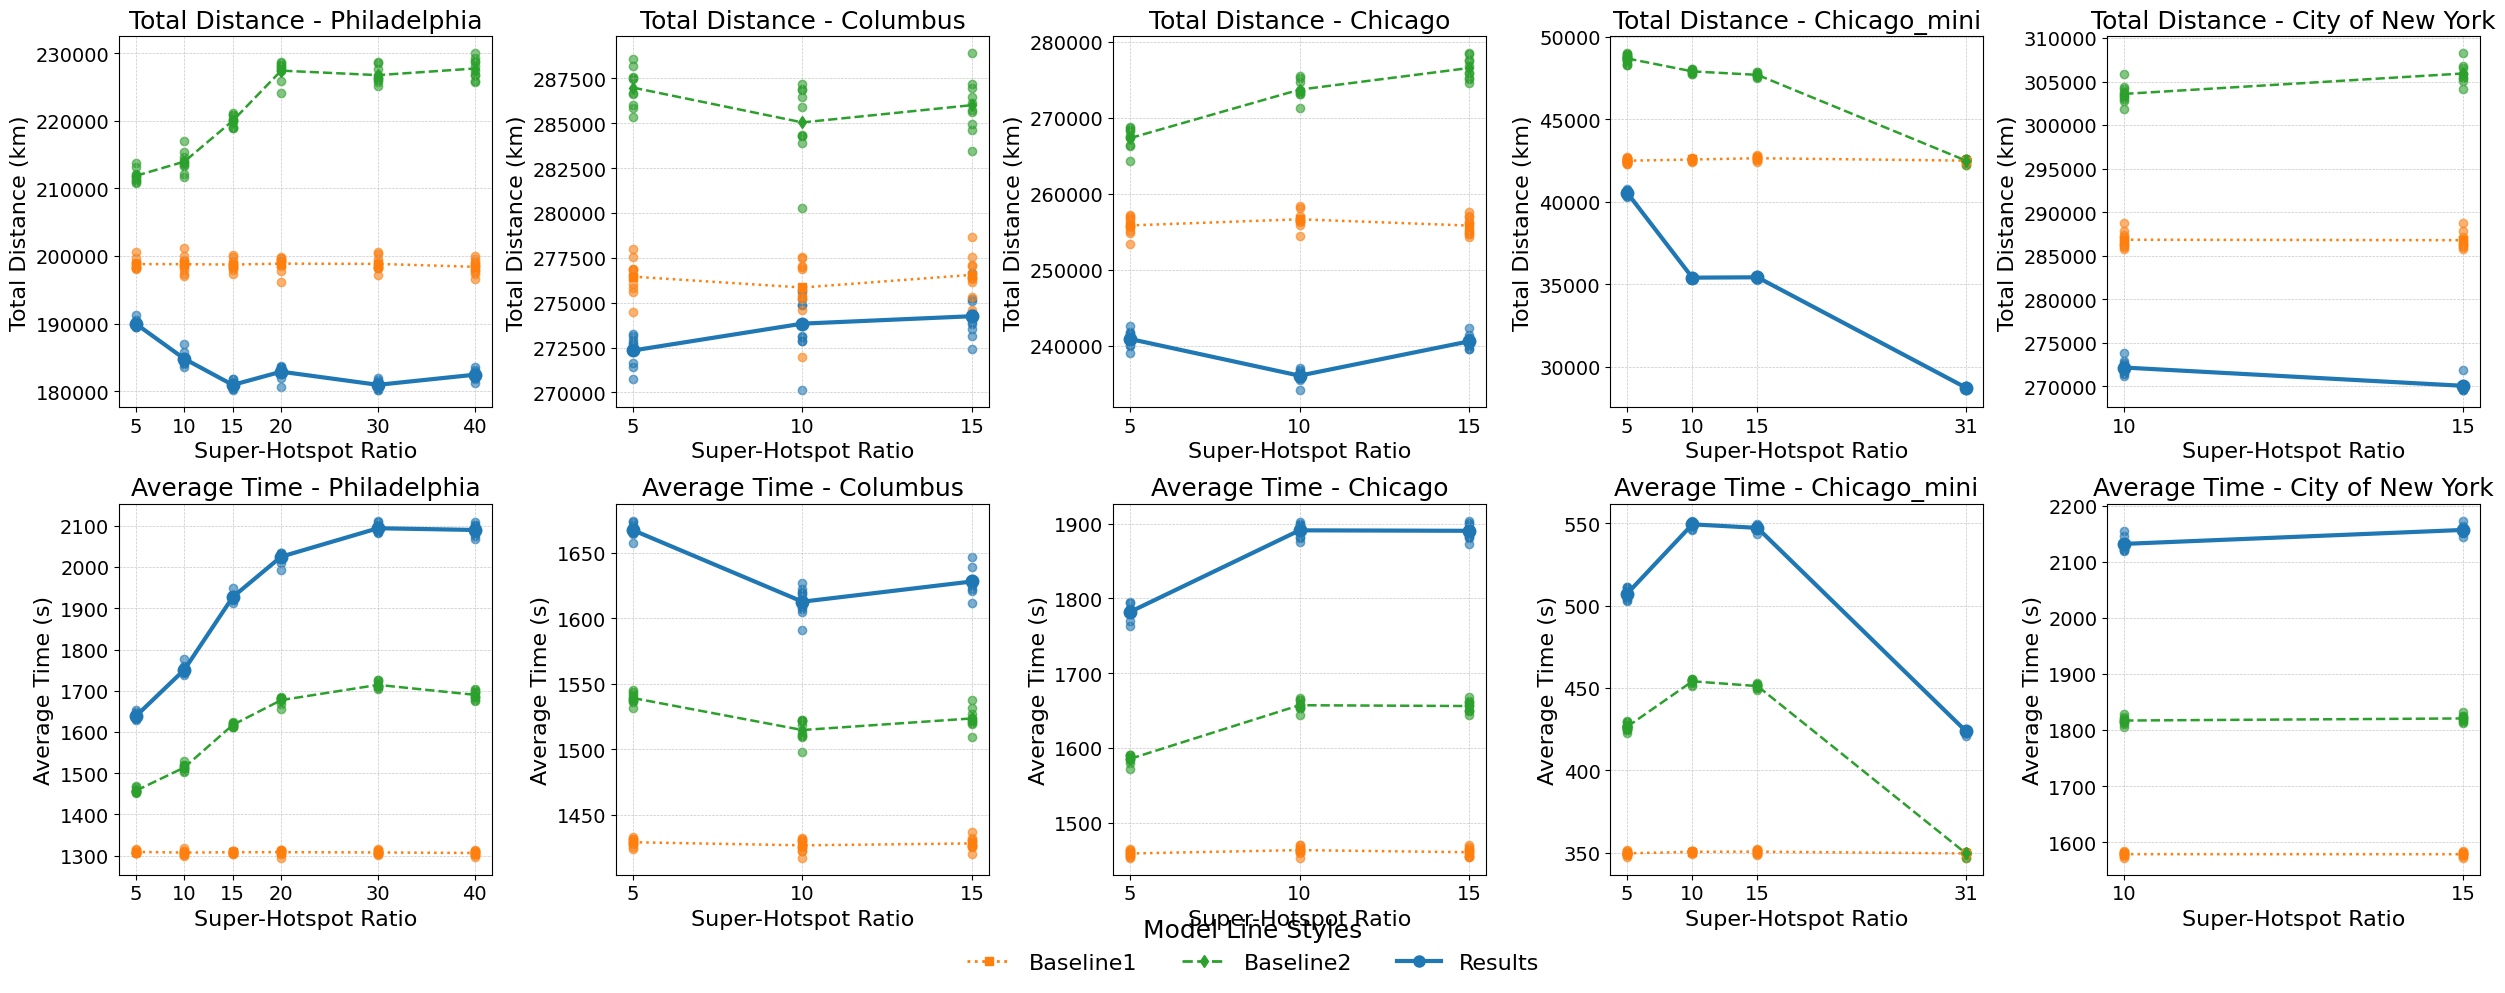

In [8]:
# plot_results
plot_results(city_results_dict, models)

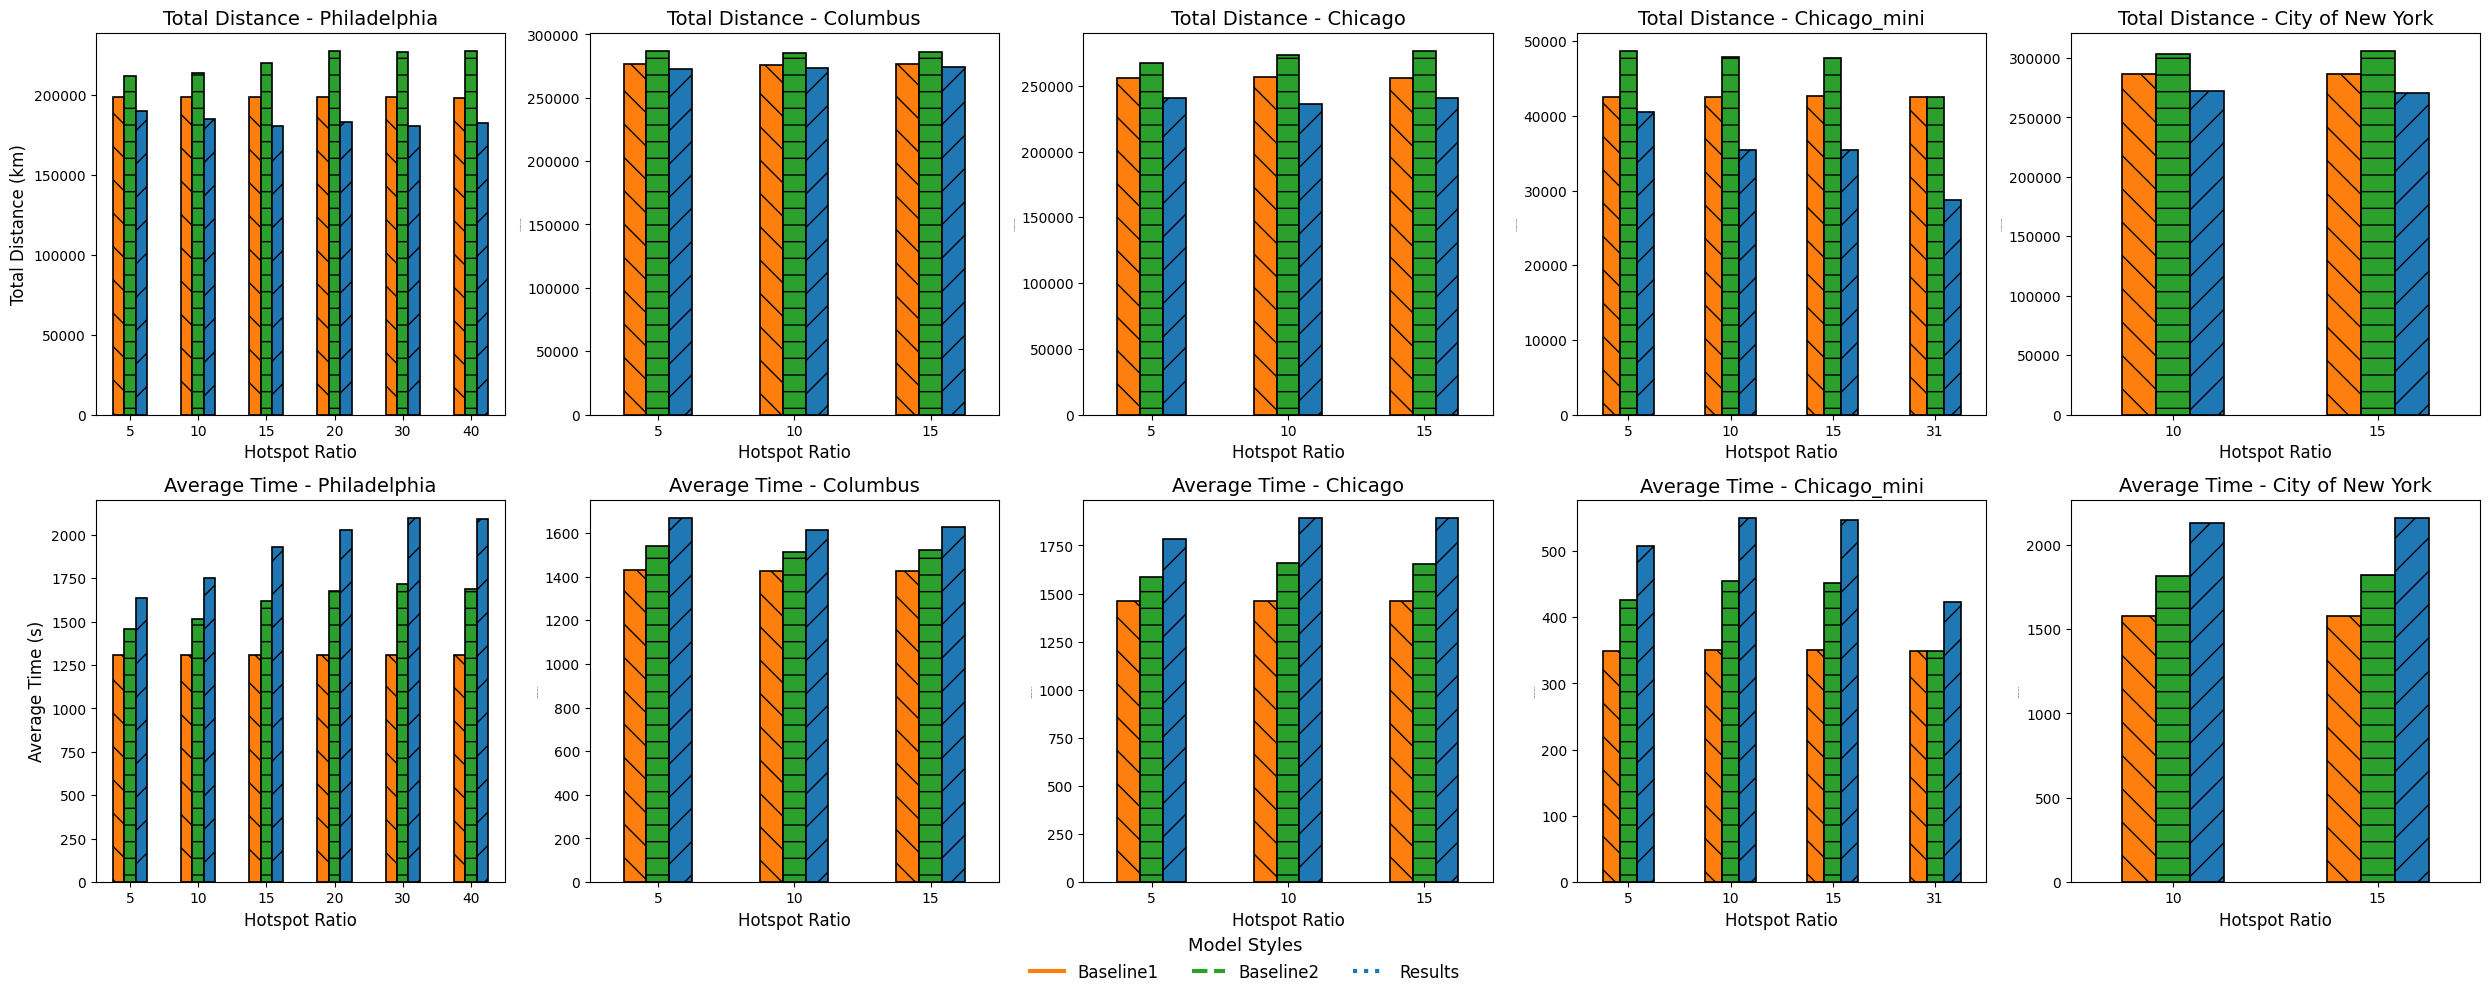

In [9]:
# Call this function plot_all_cities_bar_plot
plot_all_cities_bar_plot(city_results_dict, models)


# Shaded Graph for Success Rate

In [10]:
# ONLY FOR 1-15 RATIOS
# Extract success rate data for the "Results" model across all cities
success_rate_data_all = []

for city, results in city_results_dict.items():
  for ratio in sorted(results.keys()):
    if "results" in results[ratio] and ratio <= 15:  # Ensure only "Results" model is considered for ratios 15 or below
      success_rates = results[ratio]["results"]["success_rate"]
      for rate in success_rates:
        success_rate_data_all.append({"City": city, "Success Rate": rate*100, "Ratio":ratio, "Model": "results"})  # Fixed incorrect model reference

xs_all = np.array([5, 10, 15])

In [11]:
# ONLY FOR CHICAGO MINI AND PHILADELPHIA
# Extract success rate data for the "Results" model across all cities
success_rate_data_phil_chicmini = []
cities_to_check = ['Chicago_mini', 'Philadelphia']
for city, results in city_results_dict.items():
  if city in cities_to_check:
    for ratio in sorted(results.keys()):
     if "results" in results[ratio]:
      success_rates = results[ratio]["results"]["success_rate"]
      for rate in success_rates:
        success_rate_data_phil_chicmini.append({"City": city, "Success Rate": rate*100, "Ratio":ratio, "Model": "results"})  # Fixed incorrect model reference

xs_phil_chicmini = np.array([5, 10, 15, 20, 30, 31, 40])

In [12]:
# Convert to DataFrame
def create_graph(success_rate_data, xs):
  df_success_rate = pd.DataFrame(success_rate_data)

  # Compute mean, standard deviation, and variance per city
  grouped = df_success_rate.groupby(["City", "Ratio"])["Success Rate"]

  means = grouped.mean().unstack(level=0)
  means_mask = np.isfinite(means)

  stds = grouped.std().unstack(level=0)
  stds_mask = np.isfinite(stds)

  # Assign numerical indices to cities for plotting
  city_mapping = {city: idx for idx, city in enumerate(means.index)}
  city_indices = np.array(list(city_mapping.values()))

  # Plot
  fig, ax = plt.subplots(figsize=(10, 6))
  sns.set(style="whitegrid")

  print(df_success_rate["City"].value_counts())

  # Plot individual success rate data points as scatter points (semi-transparent gray)
  city_palette = sns.color_palette("Set2", n_colors=len(df_success_rate["City"].unique()))
  city_colors = {city: city_palette[i] for i, city in enumerate(df_success_rate["City"].unique())}

  sns.scatterplot(
      data=df_success_rate,
      x="Ratio",
      y="Success Rate",
      hue="City",
      alpha=0.4,
      palette=city_colors
  )

  # Plot mean success rate as a line (Green with markers)
  # plt.plot(city_indices, means, marker="o", linestyle="-", color="green", label="Mean Success Rate", linewidth=2)

  cities = df_success_rate["City"].unique()

  # For reference: https://stackoverflow.com/questions/14399689/matplotlib-drawing-lines-between-points-ignoring-missing-data
  for city in means.columns:
    ax.plot(
      xs[means_mask[city]],
      np.array(means[city])[means_mask[city]],
      marker="o", linestyle="-",
      label=city,
      color=city_colors[city]
    )

  # Add shaded standard deviation interval (Green)
  # plt.fill_between(city_indices, means - stds, means + stds, color="green", alpha=0.3, label="Std. Dev. Interval")
  for city in means.columns:
    ax.fill_between(
      xs[means_mask[city]],
      (np.array(means[city]) - np.array(stds[city]))[means_mask[city]],
      (np.array(means[city]) + np.array(stds[city]))[means_mask[city]],
      alpha=0.3,
      color=city_colors[city]
    )


  ax.set_ylim(ymin=60)

  # Labels & Title
  ax.set_title("Success Rate per Ratio with Shaded Standard Deviation for all Cities", fontsize=14)
  ax.set_xlabel("Ratio", fontsize=12)
  ax.set_ylabel("Success Rate (%)", fontsize=12)
  # ax.legend()

  # Show plot
  plt.show()

City
Chicago_mini        40
Philadelphia        30
Columbus            30
Chicago             30
City of New York    19
Name: count, dtype: int64


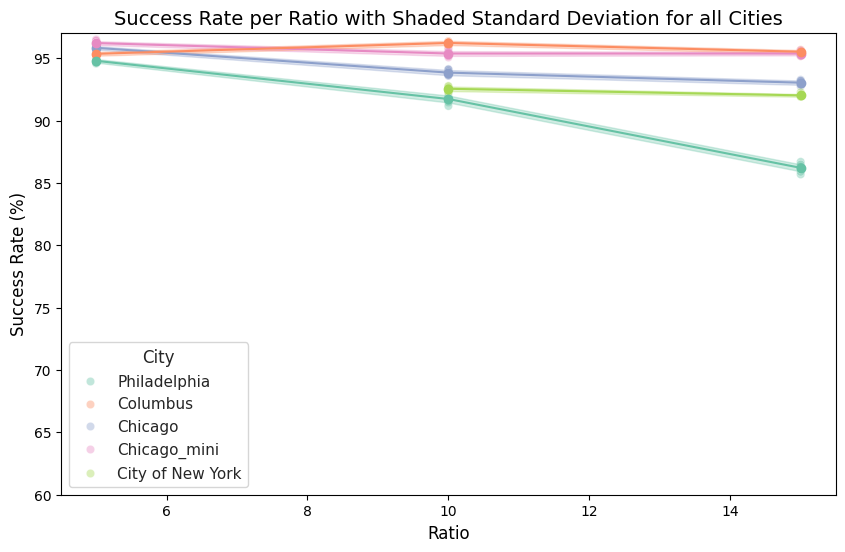

City
Philadelphia    60
Chicago_mini    50
Name: count, dtype: int64


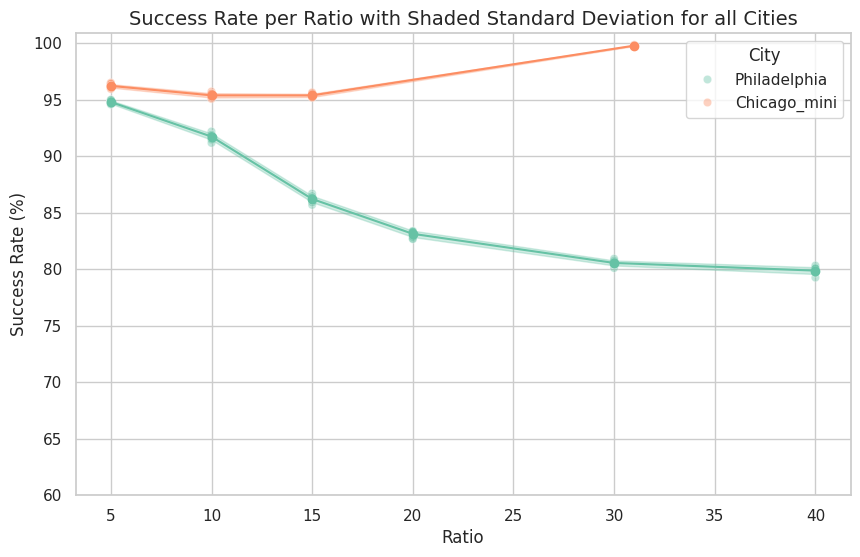

In [13]:
create_graph(success_rate_data_all, xs_all)

create_graph(success_rate_data_phil_chicmini, xs_phil_chicmini)

#### Same plot as above but only for Philadelphia

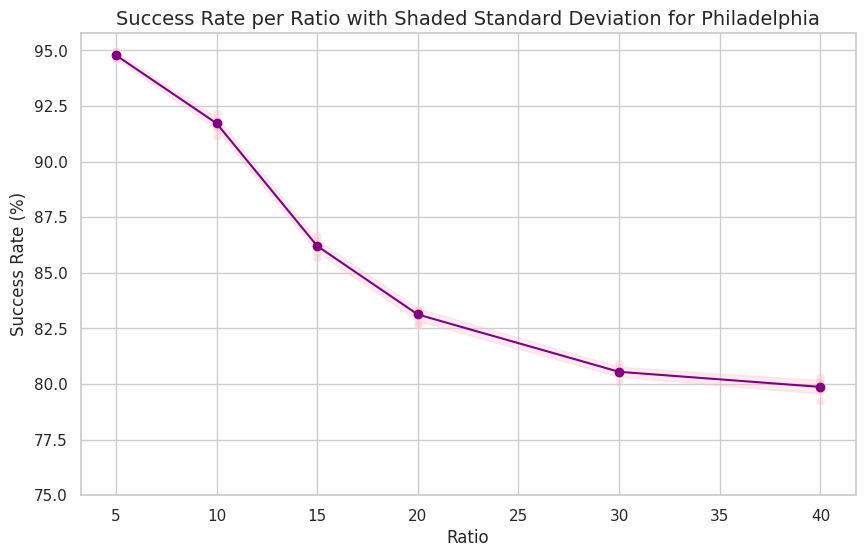

In [14]:
# Get success rates only for Philadelphia
phil_success_rate_data = []
phil_results = city_results_dict['Philadelphia']
for ratio in sorted(phil_results.keys()):
  if "results" in phil_results[ratio]:
    success_rates = phil_results[ratio]["results"]["success_rate"]
    for rate in success_rates:
      phil_success_rate_data.append({"Success Rate": rate*100, "Ratio":ratio, "Model": "results"})

# Convert to DF
df_phil_success_rate = pd.DataFrame(phil_success_rate_data)

# Group by ratio and get success rate
phil_grouped = df_phil_success_rate.groupby(["Ratio"])["Success Rate"]
phil_xs = np.array([5, 10, 15, 20, 30, 40])  # Setting X

# Getting means and std devs
phil_means = phil_grouped.mean()
phil_stds = phil_grouped.std()


# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.set(style="whitegrid")

# Plot individual points
sns.scatterplot(
    data=df_phil_success_rate,
    x="Ratio",
    y="Success Rate",
    alpha=0.4,
    color="pink"
)

# Plot line and std dev fill
ax.plot(phil_xs, np.array(phil_means), marker="o", linestyle="-", color="purple")
ax.fill_between(phil_xs, (np.array(phil_means) - np.array(phil_stds)), (np.array(phil_means) + np.array(phil_stds)), alpha=0.3, color="pink")

ax.set_ylim(ymin=75)  # Set min y axis value to 75

# Set title and labels
ax.set_title("Success Rate per Ratio with Shaded Standard Deviation for Philadelphia", fontsize=14)
ax.set_xlabel("Ratio", fontsize=12)
ax.set_ylabel("Success Rate (%)", fontsize=12)

plt.show()

#### Same plot but only for Chicago Mini

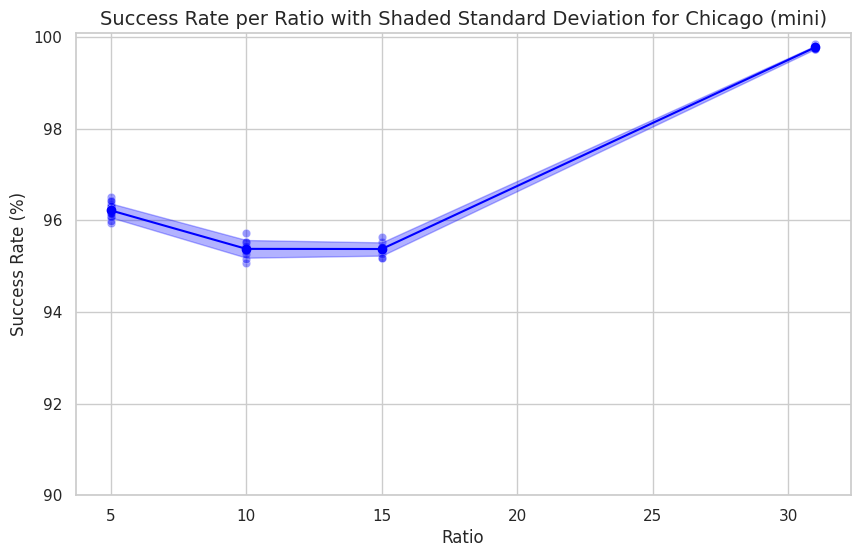

In [15]:
# Get success rates only for Philadelphia
mini_success_rate_data = []
mini_results = city_results_dict['Chicago_mini']
for ratio in sorted(mini_results.keys()):
  if "results" in mini_results[ratio]:
    success_rates = mini_results[ratio]["results"]["success_rate"]
    for rate in success_rates:
      mini_success_rate_data.append({"Success Rate": rate*100, "Ratio":ratio, "Model": "results"})

# Convert to DF
df_mini_success_rate = pd.DataFrame(mini_success_rate_data)

# Group by ratio and get success rate
mini_grouped = df_mini_success_rate.groupby(["Ratio"])["Success Rate"]
mini_xs = np.array([5, 10, 15, 31])  # Setting X

# Getting means and std devs
mini_means = mini_grouped.mean()
mini_stds = mini_grouped.std()


# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.set(style="whitegrid")

# Plot individual points
sns.scatterplot(
    data=df_mini_success_rate,
    x="Ratio",
    y="Success Rate",
    alpha=0.4,
    color="blue"
)

# Plot line and std dev fill
ax.plot(mini_xs, np.array(mini_means), marker="o", linestyle="-", color="blue")
ax.fill_between(mini_xs, (np.array(mini_means) - np.array(mini_stds)), (np.array(mini_means) + np.array(mini_stds)), alpha=0.3, color="blue")

ax.set_ylim(ymin=90)  # Set min y axis value to 90

# Set title and labels
ax.set_title("Success Rate per Ratio with Shaded Standard Deviation for Chicago (mini)", fontsize=14)
ax.set_xlabel("Ratio", fontsize=12)
ax.set_ylabel("Success Rate (%)", fontsize=12)

plt.show()

# **From now on the following code is for Plot graph of Columbus for different load**

In [16]:
#2nd version
def extract_metrics_col(json_files):
    """
    Extracts and averages total distance, average time, success rate, and accuracy from multiple JSON files.
    """
    total_distances = []
    average_times = []
    success_rates = []
    accuracies = []

    for file_path in json_files:
        with open(file_path, 'r') as file:
            data = json.load(file)

        if "distances" in data and len(data["distances"]) > 0:
            total_distances.append(sum(data["distances"]))

        if "times" in data and len(data["times"]) > 0:
            average_times.append(sum(data["times"]) / len(data["times"]))

        if "success_rate" in data:
            success_rates.append(data["success_rate"])

        if "accuracy" in data:  # Assuming "accuracy" field exists in JSON
            accuracies.append(data["accuracy"])

    # Compute averages for each metric
    return {
        "total_distance": np.mean(total_distances) if total_distances else 0,
        "average_time": np.mean(average_times) if average_times else 0,
        "success_rate": np.mean(success_rates) if success_rates else 0,
        "accuracy": np.mean(accuracies) if accuracies else 0
    }

def process_columbus_12_15(base_directory, load_levels, models):
    """
    Processes all JSON files in a directory, groups by load values, and averages metrics.
    """
    results = {}

    for model in models:
        results[model] = {}

        for load in load_levels:
            # Find all JSON files matching the load pattern
            json_files = [
                os.path.join(base_directory, f) for f in os.listdir(base_directory)
                if f.startswith(model) and f"-{str(load).zfill(4)}-" in f and f.endswith(".json")
            ]
            metrics = extract_metrics_col(json_files)  # Compute averages

            if metrics:  # Store valid data
                results[model][load] = metrics

    return results


def plot_columbus_12_15(city_result, load_levels):
    """
    Plots multiple metrics including Total Distance, Average Time, Success Rate, and Accuracy.
    Also annotates success rate (%) values above bars in Total Distance and Average Time graphs.
    """
    models = list(city_result.keys())  # Get all models (results, baseline1, baseline2)

    # Define the color mapping for models
    model_colors = {
        "results": "#1f77b4",  # Blue
        "baseline1": "#ff7f0e",  # Orange
        "baseline2": "#2ca02c",  # Green
    }

    # Initialize data storage for plotting
    total_distance_data = {model: [] for model in models}
    average_time_data = {model: [] for model in models}
    success_rate_data = {model: [] for model in models}
    accuracy_data = {model: [] for model in models}

    # Extract data for plotting
    for model in models:
        for load in load_levels:
            if load in city_result.get(model, {}):  # Ensure model and data exist
                total_distance_data[model].append(city_result[model][load]["total_distance"])
                average_time_data[model].append(city_result[model][load]["average_time"])
                success_rate_data[model].append(city_result[model][load]["success_rate"] * 100)  # Convert to percentage
                accuracy_data[model].append(city_result[model][load]["accuracy"] * 100)  # Convert to percentage
            else:
                total_distance_data[model].append(None)  # Use None instead of 0 to avoid misleading values
                average_time_data[model].append(None)
                success_rate_data[model].append(None)
                accuracy_data[model].append(None)

    # Convert data for bar plotting
    x = np.arange(len(load_levels))  # X-axis positions
    width = 0.8 / len(models)  # Dynamically adjust bar width

    # Create a figure with 4 subplots for different metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

    # Function to add annotations above bars
    def add_annotations(ax, data, success_rate):
        """ Adds success rate values as annotations above bars (vertically). """
        max_value = max([max(d) for d in data.values() if d])  # Get max value across models
        ax.set_ylim(0, max_value * 1.15)  # Increase y-limit to create space for text

        for i, model in enumerate(models):
            for j, value in enumerate(data[model]):
                if value is not None:
                    success_value = success_rate[model][j]
                    ax.text(x[j] + i * width, value + (max_value * 0.05), f"{success_value:.1f}%",
                            ha='center', fontsize=9, fontweight='bold', color="black", rotation=90)

    # Plot Total Distance vs Load Level
    for i, model in enumerate(models):
        color = model_colors.get(model, "gray")
        axes[0].bar(x + i * width, total_distance_data[model], width=width, color=color, label=model)
    axes[0].set_xlabel("Load Level")
    axes[0].set_ylabel("Total Distance")
    axes[0].set_title("Total Distance vs Load Level")
    axes[0].set_xticks(x + width * (len(models) / 2))
    axes[0].set_xticklabels(load_levels)
    axes[0].grid(axis='y', linestyle="--", alpha=0.7)

    # Add success rate annotations to Total Distance graph
    add_annotations(axes[0], total_distance_data, success_rate_data)

    # Plot Average Time vs Load Level
    for i, model in enumerate(models):
        color = model_colors.get(model, "gray")
        axes[1].bar(x + i * width, average_time_data[model], width=width, color=color)
    axes[1].set_xlabel("Load Level")
    axes[1].set_ylabel("Average Time")
    axes[1].set_title("Average Time vs Load Level")
    axes[1].set_xticks(x + width * (len(models) / 2))
    axes[1].set_xticklabels(load_levels)
    axes[1].grid(axis='y', linestyle="--", alpha=0.7)

    # Add success rate annotations to Average Time graph
    add_annotations(axes[1], average_time_data, success_rate_data)

    # Plot Success Rate vs Load Level
    for i, model in enumerate(models):
        color = model_colors.get(model, "gray")
        axes[2].bar(x + i * width, success_rate_data[model], width=width, color=color)
    axes[2].set_xlabel("Load Level")
    axes[2].set_ylabel("Success Rate (%)")
    axes[2].set_title("Success Rate vs Load Level")
    axes[2].set_xticks(x + width * (len(models) / 2))
    axes[2].set_xticklabels(load_levels)
    axes[2].grid(axis='y', linestyle="--", alpha=0.7)

    # Plot Accuracy vs Load Level (Separate Graph)
    for i, model in enumerate(models):
        color = model_colors.get(model, "gray")
        axes[3].bar(x + i * width, accuracy_data[model], width=width, color=color)
    axes[3].set_xlabel("Load Level")
    axes[3].set_ylabel("Accuracy (%)")
    axes[3].set_title("Accuracy vs Load Level")
    axes[3].set_xticks(x + width * (len(models) / 2))
    axes[3].set_xticklabels(load_levels)
    axes[3].grid(axis='y', linestyle="--", alpha=0.7)

    # Add a common legend at the bottom of the figure
    fig.legend(models, loc='lower center', ncol=len(models), bbox_to_anchor=(0.5, -0.1))

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


Files in base directory: ['results_0-0300-001-010-[0.25, 0.75]-062-02_12_15_0.json', 'baseline1_0-0300-001-010-[0.25, 0.75]-062-02_12_15_0.json', 'baseline2_0-0300-001-010-[0.25, 0.75]-062-02_12_15_0.json', 'results_0-0300-001-010-[0.25, 0.75]-062-03_12_15_1.json', 'baseline1_0-0300-001-010-[0.25, 0.75]-062-03_12_15_1.json', 'baseline2_0-0300-001-010-[0.25, 0.75]-062-03_12_15_1.json', 'results_0-0300-001-010-[0.25, 0.75]-062-04_12_15_2.json', 'baseline1_0-0300-001-010-[0.25, 0.75]-062-04_12_15_2.json', 'baseline2_0-0300-001-010-[0.25, 0.75]-062-04_12_15_2.json', 'results_0-0300-001-010-[0.25, 0.75]-062-05_12_15_3.json', 'baseline1_0-0300-001-010-[0.25, 0.75]-062-05_12_15_3.json', 'baseline2_0-0300-001-010-[0.25, 0.75]-062-05_12_15_3.json', 'results_0-0300-001-010-[0.25, 0.75]-062-06_12_15_4.json', 'baseline1_0-0300-001-010-[0.25, 0.75]-062-06_12_15_4.json', 'baseline2_0-0300-001-010-[0.25, 0.75]-062-06_12_15_4.json', 'results_0-0300-001-010-[0.25, 0.75]-062-07_12_15_5.json', 'baseline1

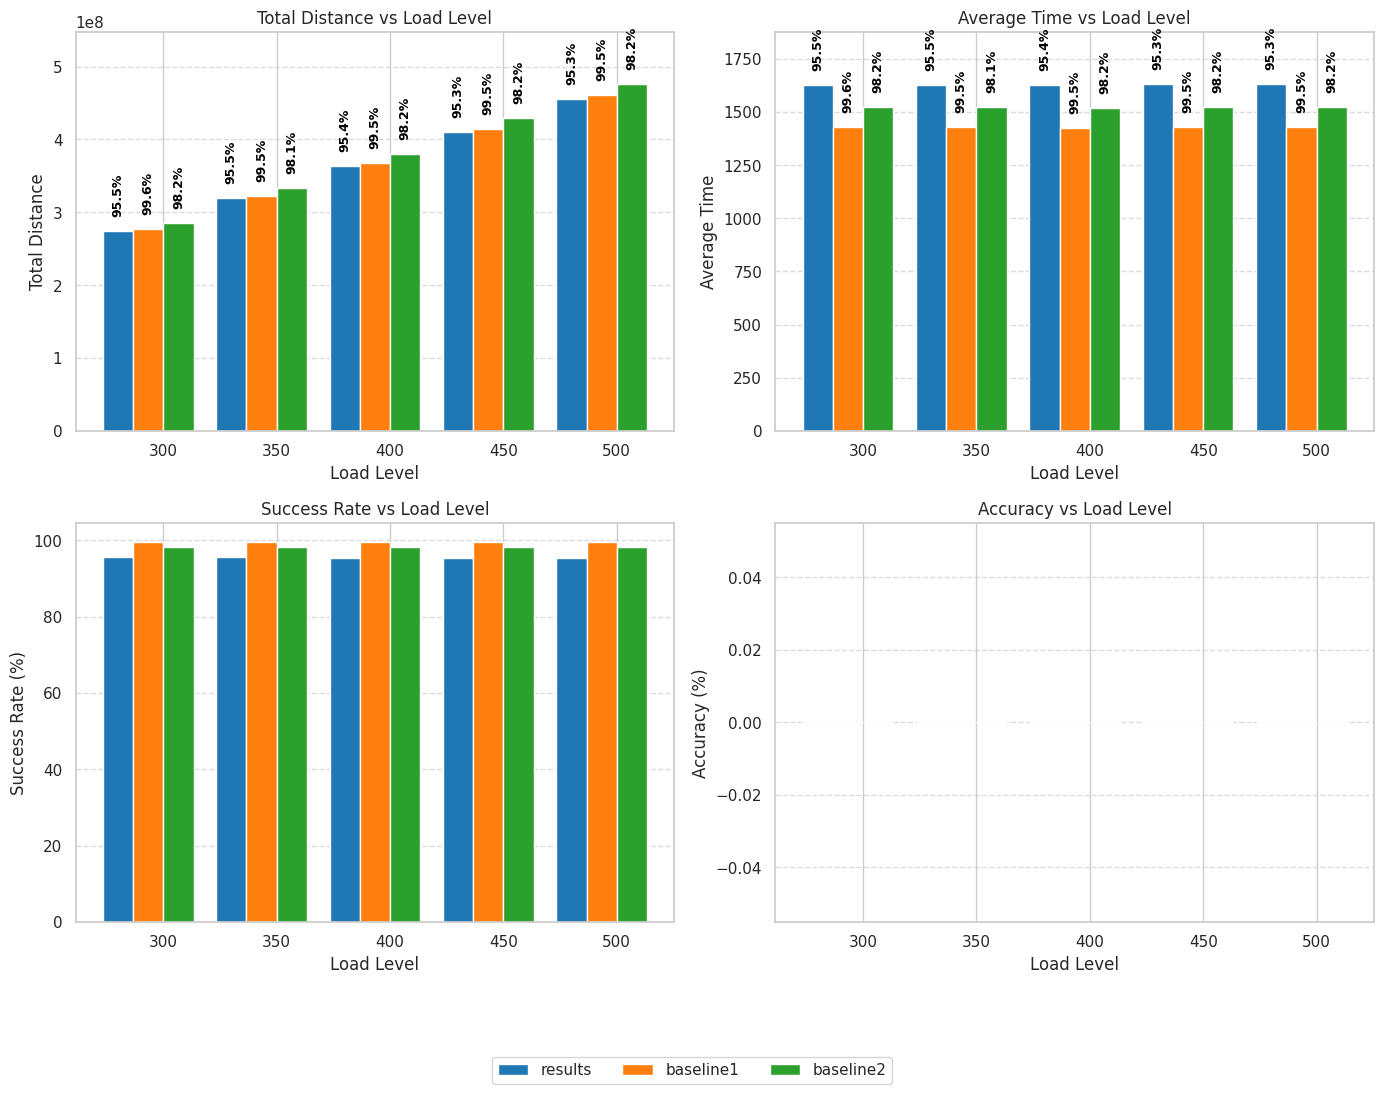

In [17]:
# Define base path for Columbus data (modify path as needed)
city = "Columbus"
models = ["results", "baseline1", "baseline2"]
personal_dir = "./gdrive/MyDrive/DeliverAI Data Folder/"

# Define the different load levels to look for
load_levels = [300, 350, 400, 450, 500]

# Base directory where JSON files are stored
base_directory = os.path.join(personal_dir, f"{city} - RL Delivery Data", "Results", "Data-12-15", "Repeating")

# List all files in the base directory
if os.path.isdir(base_directory):
    files = os.listdir(base_directory)
    print("Files in base directory:", files)
else:
    print(f"Directory not found: {base_directory}")


city_result = process_columbus_12_15(base_directory, load_levels, models)
# print(json.dumps(city_result, indent=2))

plot_columbus_12_15(city_result, load_levels)

### **1️⃣ Results Model (QuikDel - Path Sharing)**
- This model represents the **QuikDel system** that incorporates **path-sharing** for deliveries.
- Deliveries are grouped together **whenever possible**, allowing multiple deliveries to be transported **in the same vehicle** for part of the route.
- This method **reduces total travel distance** (by up to **25%**) but may introduce **a slight increase in delivery time** due to waiting and detours for path-sharing.
- **Best for: Cities with high delivery demand where reducing vehicle movement is crucial.**

---

### **2️⃣ Baseline 1 (No Sharing, Direct Routing)**
- This model assumes that each delivery **travels directly from its origin to its destination** without any **path-sharing** or **multi-hop routing**.
- It represents a **fully connected delivery network**, meaning deliveries take the **shortest possible path**.
- **Disadvantage:** It does not **benefit from shared routes**, leading to **higher total travel distances** and **higher vehicle fuel costs**.
- **Best for: Small-scale delivery operations where delivery time is more critical than cost reduction.**

---

### **3️⃣ Baseline 2 (Hierarchical Routing Without Path Sharing)**
- This model uses a **hierarchical routing system**, meaning deliveries **follow structured paths through designated hotspots** (instead of direct routing).
- **However, it does not allow deliveries to share vehicles.** Each delivery is still handled independently.
- **Purpose:** This model helps evaluate the benefit of the **hierarchical network alone** (without sharing) compared to `baseline1`.
- **Best for: Cities with structured delivery zones but where companies want to avoid path-sharing delays.**

---

### **Key Takeaways**
| Model | Path Sharing? | Routing Type | Expected Travel Distance | Expected Delivery Time |
|--------|--------------|-------------|------------------------|----------------------|
| **Results (QuikDel)** | ✅ Yes | Hierarchical (multi-hop) | 🔽 Reduced (25% less) | 🔼 Slightly increased |
| **Baseline 1** | ❌ No | Direct (no hierarchy) | 🔼 Higher | 🔽 Fastest |
| **Baseline 2** | ❌ No | Hierarchical (multi-hop) | 🔼 Higher | 🔼 Slightly increased |

---

### **Which Model is Best?**
- **If cost savings and efficiency are important** → ✅ **Results Model (QuikDel)**
- **If fast deliveries without extra detours are required** → ❌ **Baseline 1**
- **If structured routing is preferred, but without sharing** → ❌ **Baseline 2**